In [1]:
import random
import re

from Flamant.default import PROJECT_HOME
%cd {PROJECT_HOME}

C:\Users\louis\PycharmProjects\Master_Thesis\Flamant


In [2]:
from dataset.structural.analysis import LinearAnalysis
from dataset.structural.structure import DummyTruss
from dataset.generator import DummyTrussGenerator
from dataset import DummyTrussDataset
from torch.utils.data import DataLoader
from display import *
from scipy.stats.qmc import Sobol
import matplotlib.pyplot as plt
from typing import Dict, Iterable
import numpy as np
import random

# Example structure

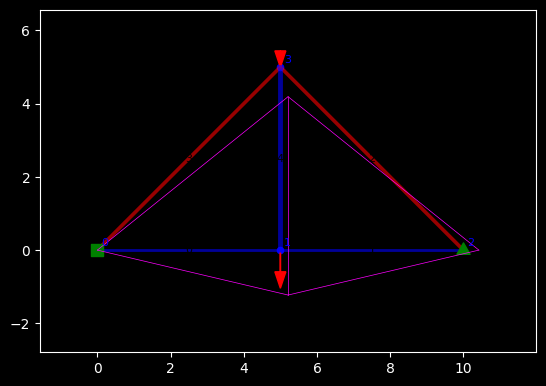

In [3]:
params = {
    'load': -1000e3,
    'volumetric_weight': 78.5e3
}

a = .01
e = 120e9

for i in range(5):
    params[f"A_{i}"] = a
    params[f"E_{i}"] = e

struct = DummyTruss()
struct.generate_model(params)
LinearAnalysis().run_analysis()
g = DummyTrussGenerator()
results = g.construct_result(params)
display_structure(def_scale=100)

In [4]:
def plot(g, def_scale=5):
    fig, axs = plt.subplots(2, 3, figsize=(12, 8), sharex=True, sharey=True)

    # Flatten the axes array for easier iteration
    axs = axs.flatten()

    for i, r in enumerate(g):
        if i >= 6:  # Since we have 2x3=6 subplots
            break

        display_structure(ax=axs[i], def_scale=def_scale)

    # After plotting all structures, adjust all axes to have same limits
    x_min, x_max = float('inf'), float('-inf')
    y_min, y_max = float('inf'), float('-inf')

    # Find global min and max across all subplots
    for ax in axs:
        x_limits = ax.get_xlim()
        y_limits = ax.get_ylim()
        x_min = min(x_min, x_limits[0])
        x_max = max(x_max, x_limits[1])
        y_min = min(y_min, y_limits[0])
        y_max = max(y_max, y_limits[1])

    # Make the scale the same in both directions - take the wider range
    total_range = max(x_max - x_min, y_max - y_min)
    x_center = (x_max + x_min) / 2
    y_center = (y_max + y_min) / 2

    # Apply the same limits to all subplots
    for ax in axs:
        ax.set_xlim(x_center - total_range / 2, x_center + total_range / 2)
        ax.set_ylim(y_center - total_range / 2, y_center + total_range / 2)

        # Ensure aspect ratio is equal
        ax.set_aspect('equal')

    plt.tight_layout()

In [5]:
def sobol_sample(ranges: Dict | Iterable, size, seed=None):
    sampler = Sobol(d=len(ranges), scramble=True, seed=seed)
    sampling = sampler.random(n=size)

    if isinstance(ranges, dict):
        scaled_sampling = dict()
        for i, k in enumerate(ranges.keys()):
            min_val, max_val = ranges[k]
            scaled_sampling[k] = sampling[:, i] * (max_val - min_val) + min_val
    else:
        scaled_sampling = sampling.copy()
        for i, (min_val, max_val) in enumerate(ranges):
            scaled_sampling[:, i] = sampling[:, i] * (max_val - min_val) + min_val

    return scaled_sampling

# Train set
We will generate sets of multiple size

Dataset saved to C:\Users\louis\PycharmProjects\Master_Thesis\Flamant\data\dataset\dummy_truss/val_8192.hdf5
Dataset saved to C:\Users\louis\PycharmProjects\Master_Thesis\Flamant\data\dataset\dummy_truss/val_512.hdf5


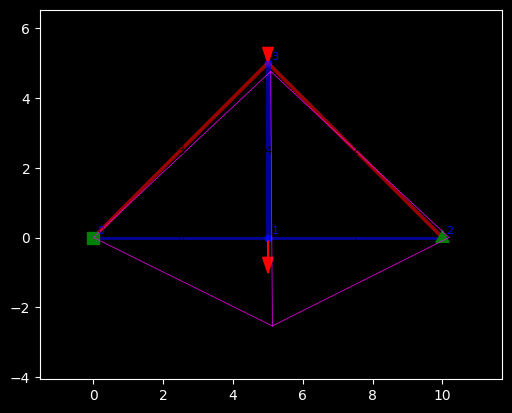

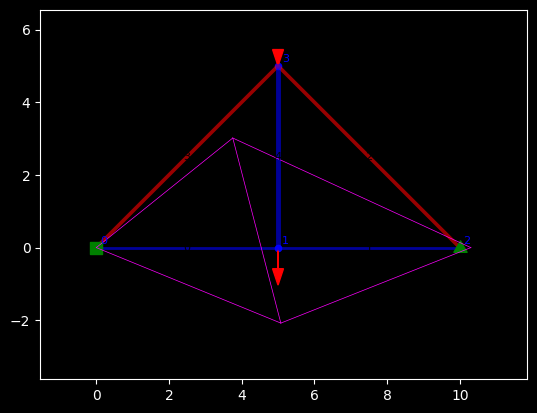

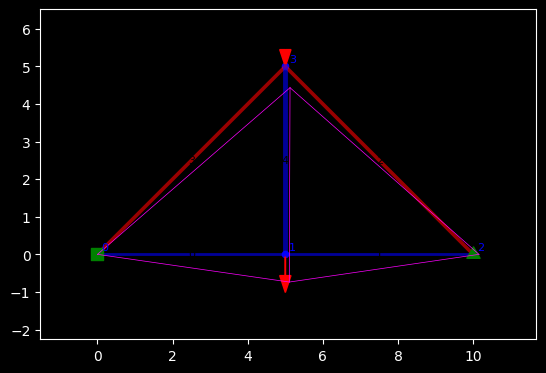

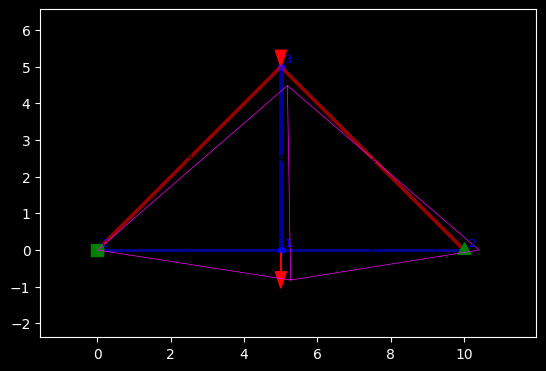

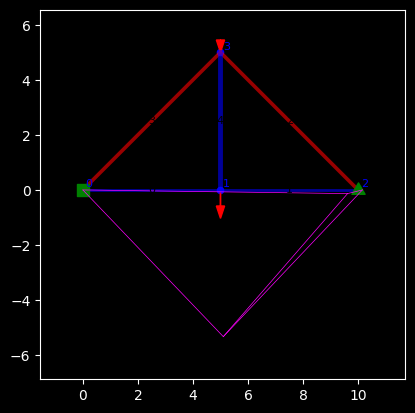

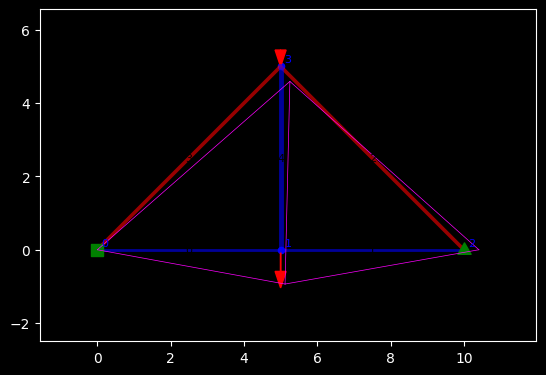

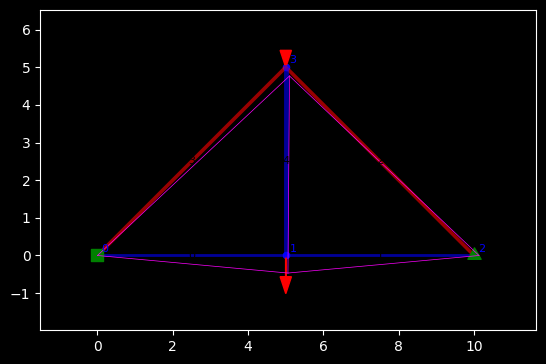

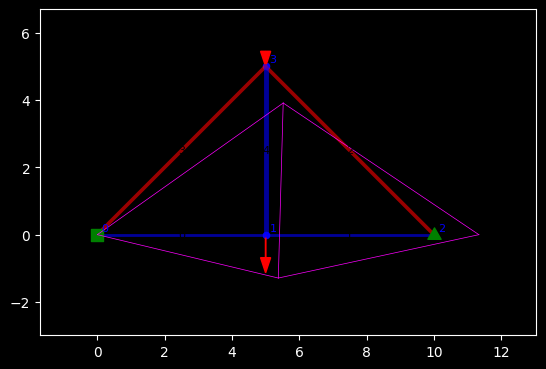

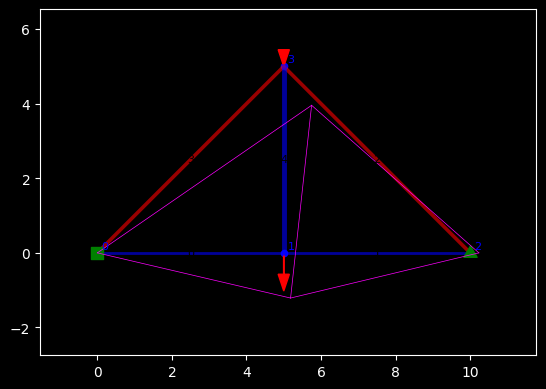

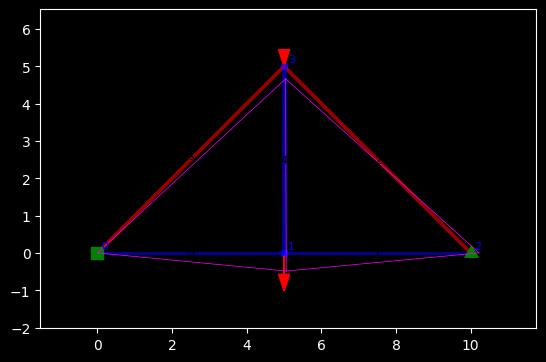

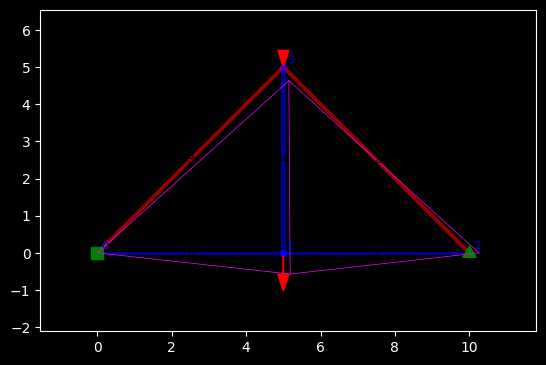

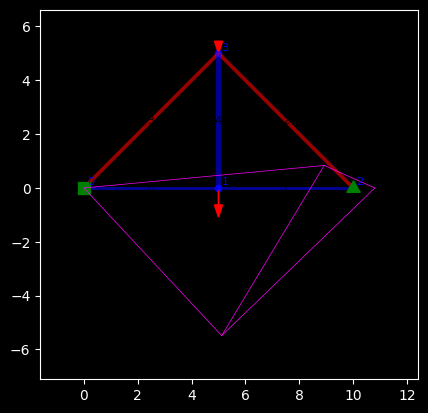

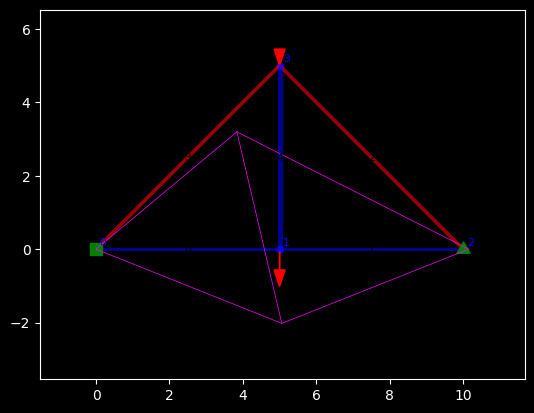

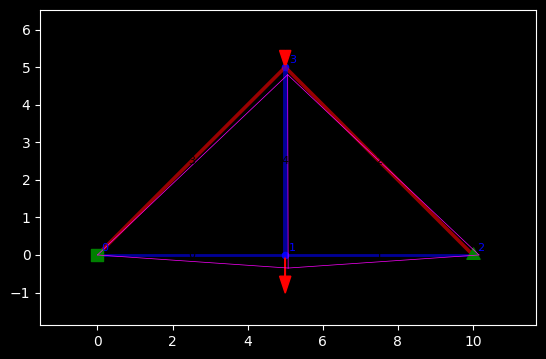

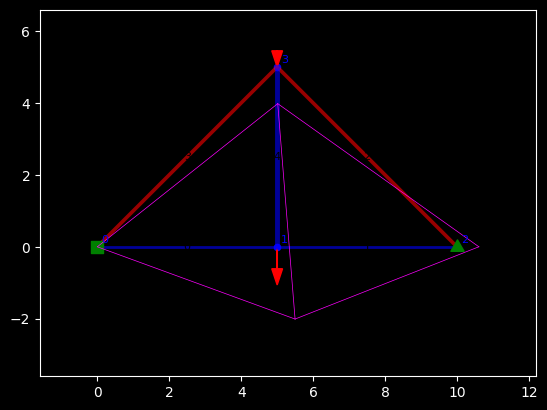

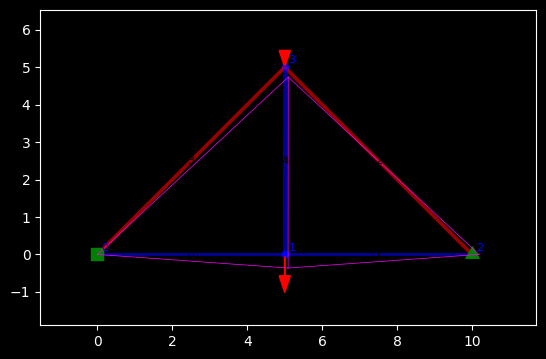

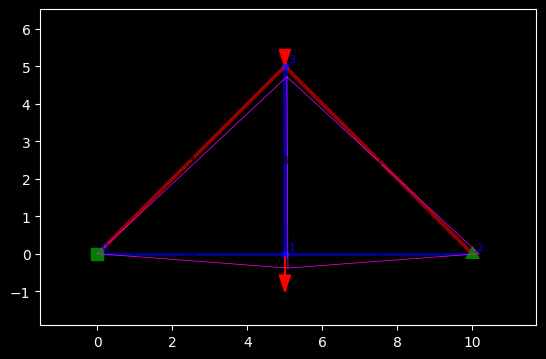

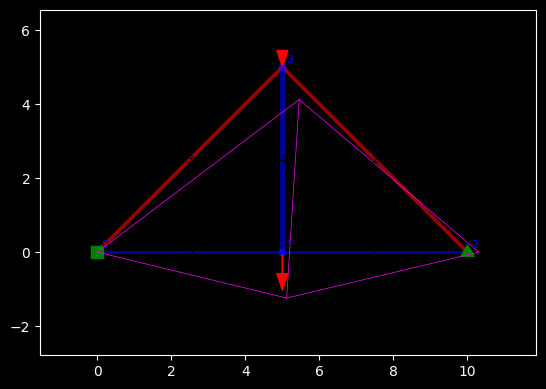

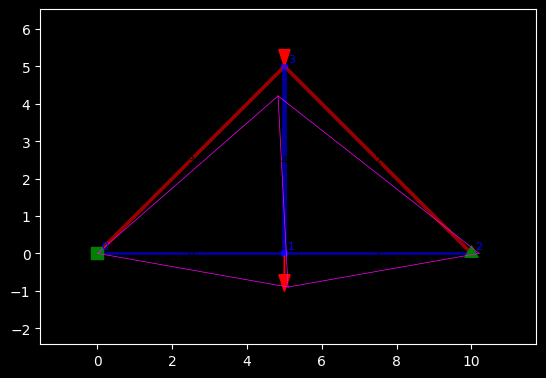

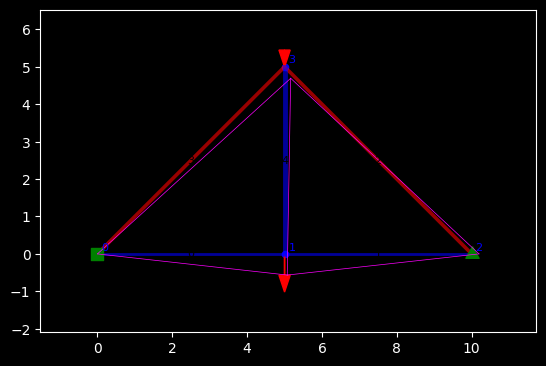

In [14]:
def generate_dataset(size, filepath, display=True,
                     young_range=(150e9, 250e9), area_range=(1e-3, 5e-2), load_range=(-10_000.e3, 0.0)):
    def routine(size, params_ranges, default_params=None):
        if default_params is None:
            default_params = {
                'volumetric_weight': 78.5e3
            }

        samples = sobol_sample(
            ranges=params_ranges,
            size=size,
        )
        results_iterator = []
        for i in range(size):
            params = default_params.copy()
            params.update({f"A_{j}": samples[f'a_{j}'][i] for j in range(5)})
            params.update({f"E_{j}": samples[f'e_{j}'][i] for j in range(5)})

            params[f"load"] = samples[f"load"][i]

            struct = DummyTruss()
            struct.generate_model(params)
            LinearAnalysis().run_analysis()
            g = DummyTrussGenerator(structure=struct)

            if i <10:
                if display: display_structure(def_scale=20)

            results_iterator.append(g.construct_result(params))

        return results_iterator

    # Random loads
    params_ranges = {f'e_{i}': young_range for i in range(5)}
    params_ranges.update({f'a_{i}': area_range for i in range(5)})
    params_ranges.update({f'load': load_range})

    results_iterator = routine(size, params_ranges)

    random.shuffle(results_iterator)  # mixing up all modes
    if filepath is not None: g.save_from_iterator(results_iterator, filepath, max_size=len(results_iterator))


    return results_iterator


#dir_path = f"data/dataset/dummy_truss"
dir_path = r"C:\Users\louis\PycharmProjects\Master_Thesis\Flamant\data\dataset\dummy_truss"
#for size in [2**i for i in range(7,13)]:
#    generate_dataset(size, f'{dir_path}/{size}.hdf5')
results = generate_dataset(8192, f'{dir_path}/val_8192.hdf5',
                           young_range=(100e9, 250e9),
                           area_range=(1e-3, 1e-1),
                           load_range=(-20_000.e3, -15_000.0e3))
results = generate_dataset(512, f'{dir_path}/val_512.hdf5',
                           young_range=(100e9, 250e9),
                           area_range=(1e-3, 1e-1),
                           load_range=(-20_000.e3, -15_000.0e3))
#results = generate_dataset(512, None,
                       #    young_range=(100e9, 250e9), area_range=(1e-3, 1e-1),
                       #    load_range=(-20_000.e3, -15_000.0e3))

In [10]:
u = np.array((4.761, -27.754,9.524, 4.762, -18.231))
q = 1000

for noise in (.01, .02):
    print(f"noise={noise}")
    print((u*np.random.normal(loc=1, scale=noise/2, size=u.shape)).round(3))
    print((q*np.random.normal(loc=1, scale=noise/2, size=1)).round(3))

noise=0.01
[  4.747 -27.903   9.539   4.728 -18.298]
[1001.102]
noise=0.02
[  4.79  -27.596   9.383   4.77  -18.295]
[997.365]
